In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

Bonus proof in exercise to Lecture 4 (enumerating V bond terms)

Calculating the number of legal terms (without considering graph equivalence) a graph is split into by collapsing legal combination of nodes

In [2]:
def a_total(n):
    return np.sum([a(n, k) for k in range(1, n+1)])

def a(n, k):
    if(n==k):
        return 1
    if(k==1): 
        # if n is not 1 (this case would be covered by the first base case), there is no way to collapse all field points into one field point without collapsing "illegal" combinations of neighbours 
        # - which are illegal because they give a hopping of 0
        return 0
    return ((k-1)*a(n-1, k) + a(n-1, k-1))

for i in range(1, 6):
    print(f"a({i}) is {a_total(i)}")

print("Contributions to a(4):")
for i in range(2, 5):
    print(f"a(4,{i}) is {a(4, i)}")

print("Contributions to a(5):")
for i in range(2, 6):
    print(f"a(5,{i}) is {a(5, i)}")

a(1) is 1
a(2) is 1
a(3) is 2
a(4) is 5
a(5) is 15
Contributions to a(4):
a(4,2) is 1
a(4,3) is 3
a(4,4) is 1
Contributions to a(5):
a(5,2) is 1
a(5,3) is 7
a(5,4) is 6
a(5,5) is 1


Exercise in Lecture 5

The following approach using Cardano's formula was tried, but this did not work because Python chooses the roots taken in calculating y inconsistently (different branches), and therefore a correct implementation of this is non-trivial. As a consequence, numpy was used - although similar concerns in choosing inconsistent roots were considered. In the end, the root that had a negative imaginary part (and therefore a physically meaningful, positive DoS), was chosen to be the "correct" root and this was verified by examplary checking of the asymptotic behaviour (see below). Note that Vstar is always set to 1 in these examplary plots.

Using Cardona's formula would have involved:
We solve the cubic equation for $x=G(z)$ by applying Cardano's formula (https://math.vanderbilt.edu/schectex/courses/cubic/). When starting with $ax^3+bx^2+cx+d = 0$, we use the substitution $x=y-\frac{b}{3a}$ to get the "depressed cubic": $y^3+py+qy$ with p being defined as: $p:=\frac{c}{a}-\frac{b^2}{3a^2}$ and q as: $\frac{2b^3}{27a^3}-\frac{bc}{3a^2}+\frac{d}{a}$.

The principal root of this equation is then $y = \sqrt[3]{-\frac{q}{2}+\sqrt{(\frac{q}{2})^2 + (\frac{p}{3})^3}} + \sqrt[3]{-\frac{q}{2}-\sqrt{(\frac{q}{2})^2 + (\frac{p}{3})^3}}$

This result is then "converted back" to get the solution for x: $x=y-\frac{b}{3a}$ to get the principal root.

In [3]:
FERMI_LEVEL = 0

# ATTENTION: this function gives INCORRECT answers because of the marked line - therefore the numpy version (below) is used.
def solve_cubic_equation(a, b, c, d):
    p = (c/a) - ((b**2) / (3*(a**2)))
    q = ((2*(b**3))/(27*(a**3))) - ((b*c)/(3*(a**2))) + (d/a)

    term_sqrt = np.sqrt((q/2)**2 + (p/3)**3)

    y = (-(q/2)+term_sqrt)**(1/3) + (-(q/2)-term_sqrt)**(1/3) # THIS IS THE INCONSISTENT, RISKY STEP
    x = y - (b/(3*a))
    return x

The correct implementation is done with numpy.roots:

In [4]:
FERMI_LEVEL = 0.0
ETA = 1e-5 

def solve_for_G_numpy(Delta, x, omega, print_roots = False):
    V = 1
    eta = 1e-4
    z = omega + 1j * eta
    a = V**4
    b = -2*z
    c = z**2 - Delta**2 + V**2
    d = -2*Delta*x - z + Delta
    
    coefficients = [a, b, c, d]
    # all_roots = solve_cubic_equation(a, b, c, d) (incorrect solution)
    all_roots = np.roots(coefficients) # this is numerically more stable than other ways I have tried, e.g. Cardano's formula
    
    # choosing the physical root: the one with a negative imaginary part
    imag_parts = np.imag(all_roots)
    numner_of_roots_with_negative_imaginary_part = np.sum(imag_parts < 0)
    idx_g = np.argmin(imag_parts)
    G = all_roots[idx_g] 
    if (print_roots):
        print("omega is ", omega)
        other_roots = np.delete(all_roots, idx_g)
        root1 = other_roots[0]
        root2 = other_roots[1]
        print("Root that is found by taking the root with imaginary part < 0: ", G)
        print("Other root: ", root1)
        print("Third root: ", root2)
        if omega == 0:
            print("Asymptotic behaviour in theory:  inf (omega is 0)")
        else:
            print("Asymptotic behaviour in theory: ", 1 / omega)
            print("Difference between asymptotic behaviour in theory and found G(omega + i eta) is ", np.real(1/omega - G))


    if(numner_of_roots_with_negative_imaginary_part > 1):
        print("Pay attention: two roots with negative imaginary parts found - which one is the correct one?")
    
    return G

def DoS_fermi_level_numpy(Delta, x):
    G = solve_for_G_numpy(Delta, x, FERMI_LEVEL)
    return -1.0 / np.pi * np.imag(G)

To check whether our approach of choosing the physical root aligns with the asymptotic behaviour that we expect to see, $G(z) \to \frac{1}{\omega}$ für $\omega \to \infty$, we print the different roots of the cubic:

In [5]:
omega = 1000
Delta = 1
x = 0.1

G = solve_for_G_numpy(Delta, x, omega, True)

omega is  1000
Root that is found by taking the root with imaginary part < 0:  (0.0009992019968082533-9.984059872412899e-11j)
Other root:  (1000.9991009435564+0.00010000008981157848j)
Third root:  (998.9998998544484+0.00010000001002902038j)
Asymptotic behaviour in theory:  0.001
Difference between asymptotic behaviour in theory and found G(omega + i eta) is  7.98003191746768e-07


<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_486891/3879326843.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(xs, DoSs, label=f"$\Delta=$ {Delta}")


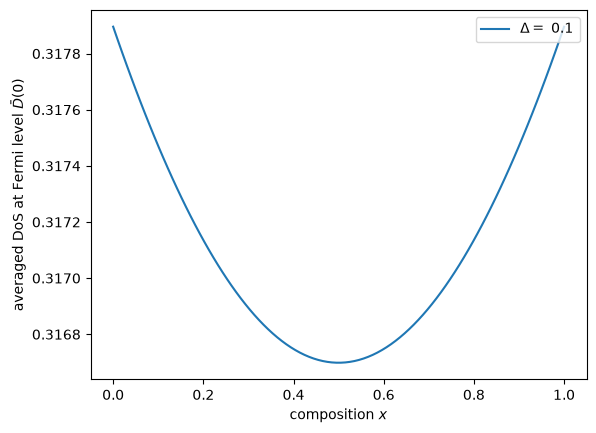

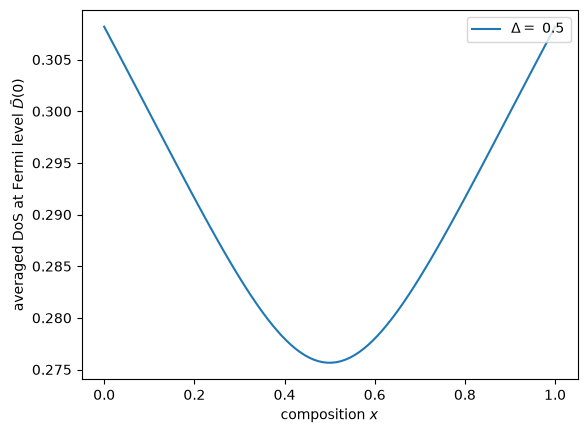

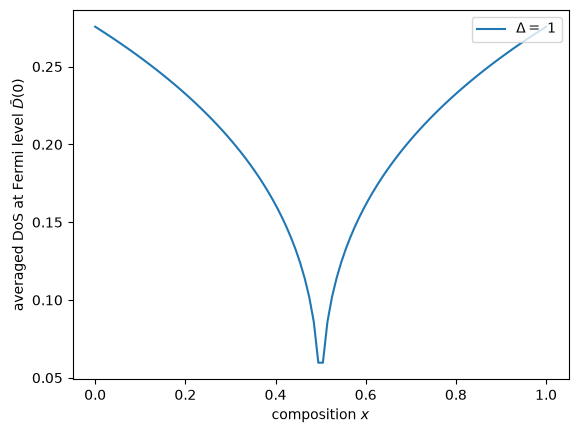

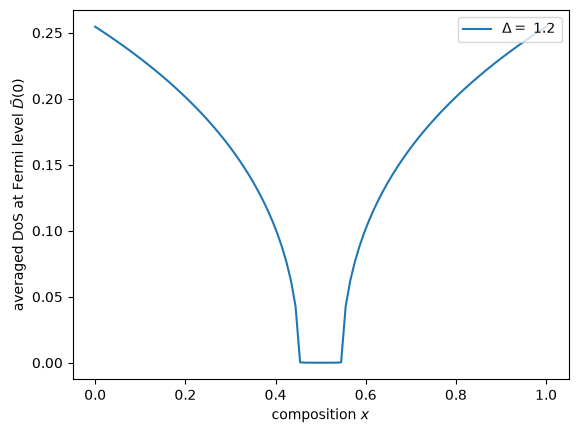

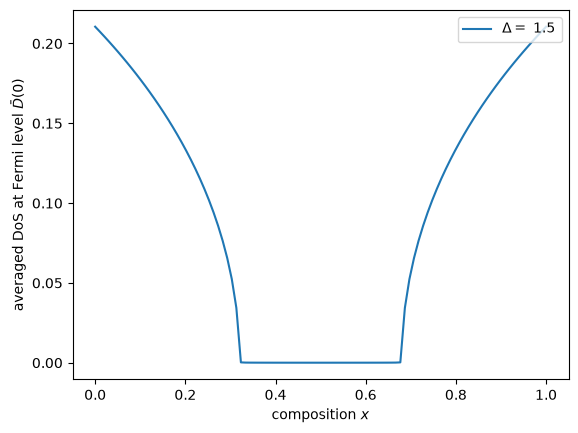

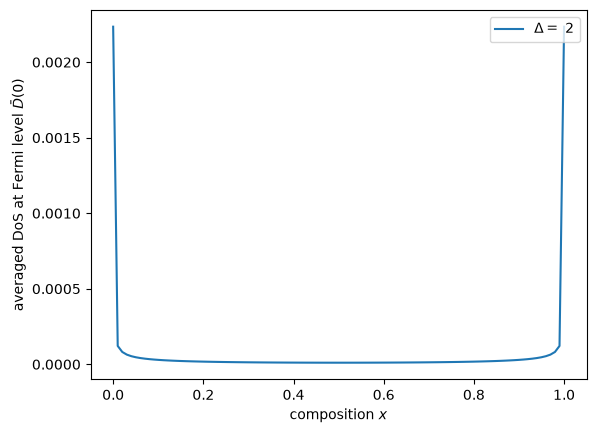

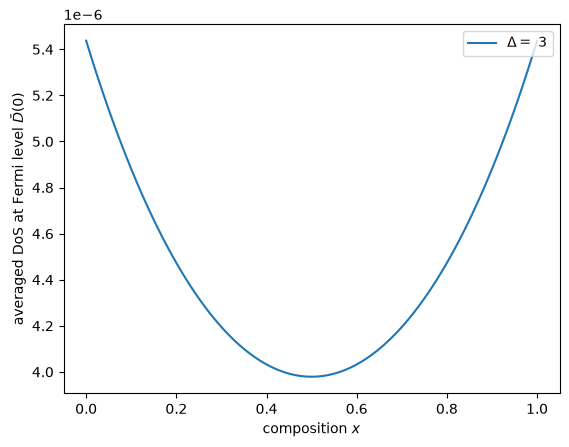

In [6]:
Deltas = [0.1, 0.5, 1, 1.2, 1.5, 2, 3]
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening

xs = np.linspace(0.0, 1.0, 100)

for Delta in Deltas:
    DoSs = []
    for x in xs:
        DoSs.append(DoS_fermi_level_numpy(Delta, x))
    plt.plot(xs, DoSs, label=f"$\Delta=$ {Delta}")
    plt.xlabel(r"composition $x$")
    plt.ylabel(r"averaged DoS at Fermi level $\bar{D}(0)$")   
    plt.legend(loc="upper right")
    plt.savefig(f"DoS_Delta_{Delta}.png", dpi=300)
    plt.show()

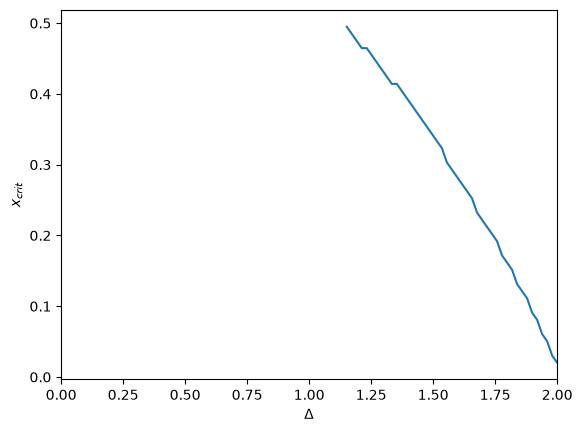

In [7]:
# Delta << 1     weak disorder / small on-site contrast
# Delta ~ 1      moderate disorder
# Delta > 1–2    strong disorder, possible band splitting / gap opening

def find_critical_x(Delta):
    eta = 1e-4
    xs = np.linspace(0.0, 1.0, 100)
    DoSs = []
    for x in xs:
        DoSs.append(DoS_fermi_level_numpy(Delta, x))
    previous_DoS = DoSs[0]
    for i in range(1, len(DoSs)-1):
        current_DoS = DoSs[i]
        if (previous_DoS > eta and current_DoS < eta):
            return xs[i]
        else:
            previous_DoS = current_DoS
    return None

Deltas = np.linspace(0.0, 2.0, 100)
x_crits = []

for Delta in Deltas:
    x_c = find_critical_x(Delta)
    x_crits.append(x_c)

plt.xlim(0, 2.0)
plt.plot(Deltas, x_crits)
plt.xlabel(r"$\Delta$")
plt.ylabel(r"$x_{crit}$")
plt.savefig("x_crit.png", dpi=300)
plt.show()

Task 8e)

In [8]:
def F(Delta):
    integrand = lambda y: np.sqrt(1-y**2) / np.sqrt(Delta**2 + 4*y**2)
    val, _ = quad(integrand, 0, 1) # numerical integration
    return 4*Delta/np.pi * val

def solve_for_U_and_mu(Delta_values):
    U_values = []
    mu_values = []

    for Delta in Delta_values:
        f = F(Delta)
        U = 2 * Delta / f
        mu = f 

        U_values.append(U)
        mu_values.append(mu)

    return np.array(U_values), np.array(mu_values)

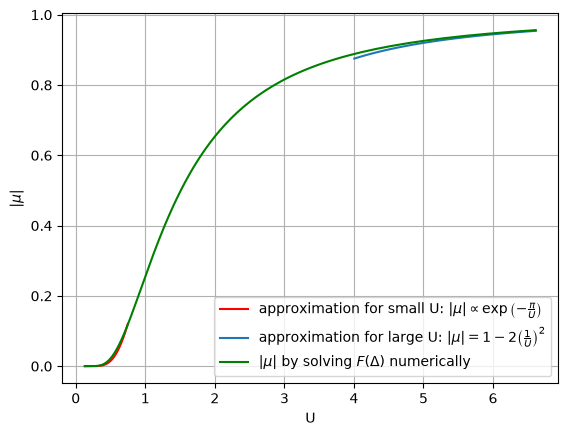

In [9]:
Delta_values = np.logspace(-10, 0.5, 800)

U_values, mu_values = solve_for_U_and_mu(Delta_values)

small_mask = U_values <= 0.75
approx_small_U = 8 * np.exp(-np.pi / U_values[small_mask])

large_mask = U_values >= 4
approx_large_U = 1 - 2* (1/ U_values[large_mask])**2

label_exp = r"$|\mu| \propto \exp\left(-\frac{\pi}{U}\right)$"
label_large_U = r"$|\mu| = 1 - 2\left(\frac{1}{U}\right)^2$"
label_mu = r"$|\mu|$ by solving $F(\Delta)$ numerically"

plt.plot(U_values[small_mask], approx_small_U, color="red", label=f"approximation for small U: {label_exp}")
plt.plot(U_values[large_mask], approx_large_U, label=f"approximation for large U: {label_large_U}")

plt.plot(U_values, mu_values, label = label_mu, color="green")
plt.legend()
plt.xlabel("U")
plt.ylabel(r"$|\mu|$")
plt.grid(True)
plt.savefig("solving_for_mu.png", dpi=300)
plt.show()


Task 8f)

In [10]:
def calculate_D_A_up(omega, Delta):
    omega = np.asarray(omega)
    D = np.zeros_like(omega, dtype=float)

    edge = np.sqrt(Delta**2 + 4)

    # positive frequency region
    mask_pos = (omega >= Delta) & (omega <= edge)

    # negative frequency region (avoiding the non-integratable singularity)
    eps = 1e-14
    mask_neg = (omega >= -edge) & (omega <= -Delta - eps)

    D[mask_pos] = (
        1 / (2*np.pi)
        * np.sqrt((omega[mask_pos] - Delta) / (omega[mask_pos] + Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_pos]**2, 0))
    )

    abs_omega = np.abs(omega[mask_neg])

    D[mask_neg] = (
        1 / (2*np.pi)
        * np.sqrt((abs_omega + Delta) / (abs_omega - Delta))
        * np.sqrt(np.maximum(4 + Delta**2 - omega[mask_neg]**2, 0))
    )

    return D

In [11]:
U_targets = np.array([0.5, 1, 4]) # the examplary U values to look at

rows = []

for U_target in U_targets: 
    # because using the approach described in the lectures, 
    # we cannot claculate the DoS depending on U, but we choose Delta first, we must choose a U close to a U we have solved for already.
    idx = np.argmin(np.abs(U_values - U_target))

    rows.append({
        "U_target": U_target,
        "U_nearest": U_values[idx],
        "Delta": Delta_values[idx],
        "mu": mu_values[idx],
    })

df_U_values = pd.DataFrame(rows)
print(df_U_values)

   U_target  U_nearest     Delta        mu
0       0.5   0.500046  0.005499  0.021995
1       1.0   1.000552  0.127941  0.255740
2       4.0   4.005460  1.779561  0.888568


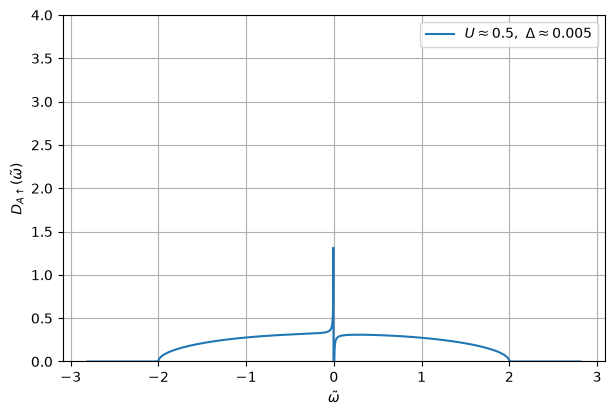

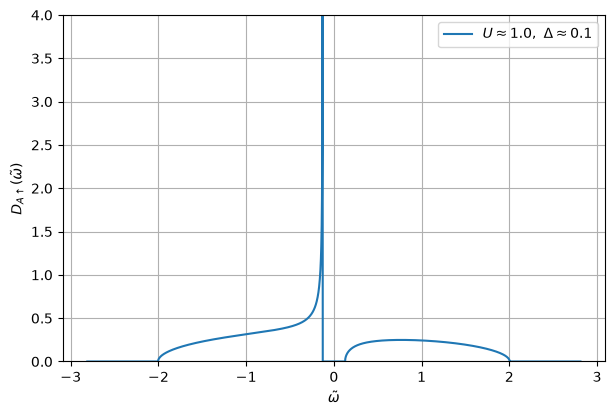

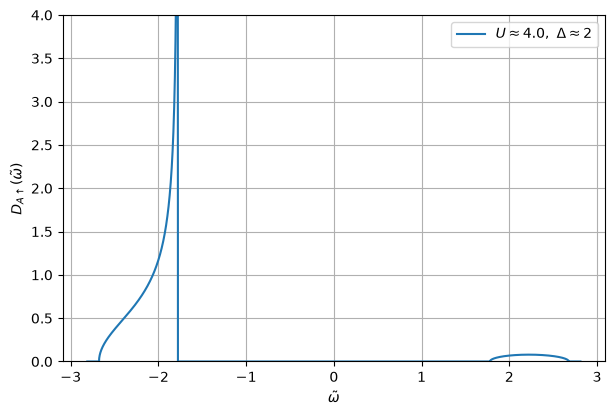

In [12]:
for U, Delta in zip(df_U_values["U_target"], df_U_values["Delta"]):
    omega_max = 1.05 * max(np.sqrt(Delta**2 + 4) for Delta in df_U_values["Delta"])
    omega = np.linspace(-omega_max, omega_max, 5000)

    plt.figure(figsize=(7, 4.5))

    D = calculate_D_A_up(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U \approx {U},\ \Delta \approx {Delta:.1g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D_{A\uparrow}(\tilde{\omega})$")
    plt.grid(True)
    plt.ylim(0, 4)
    plt.legend()
    plt.savefig(f"D_up_U_{U}.png", dpi=300)
    plt.show()

In [13]:
def calculate_D(omega, Delta):
    D_up_positive_ommega = calculate_D_A_up(omega, Delta)
    D_up_negative_omega = calculate_D_A_up(-omega, Delta)
    D = 0.5* (D_up_positive_ommega + D_up_negative_omega)
    return D

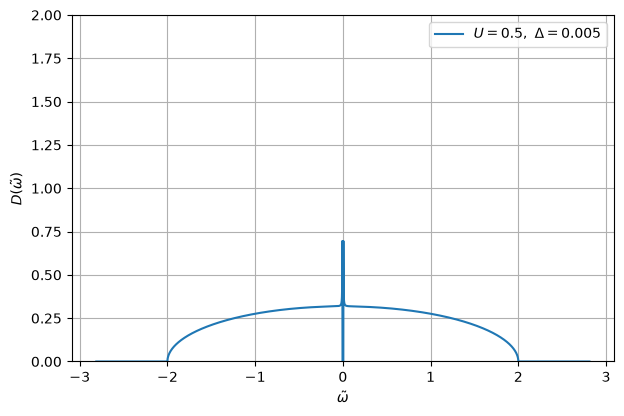

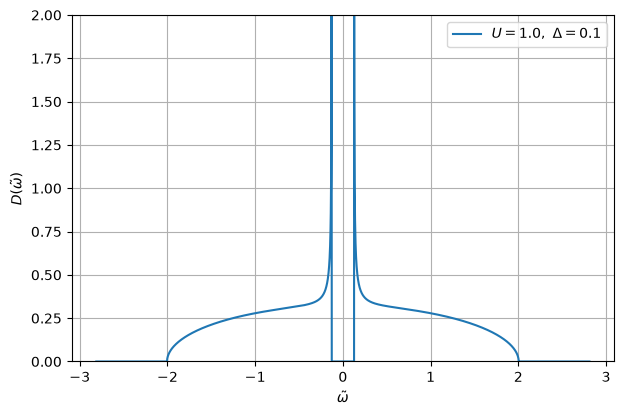

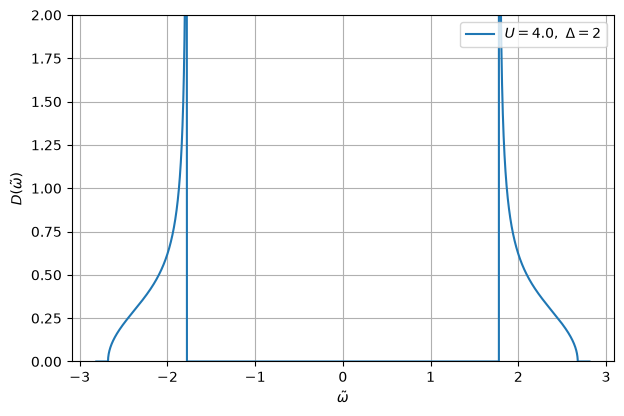

In [15]:
for U, Delta in zip(df_U_values["U_target"], df_U_values["Delta"]):
    omega_max = 1.05 * max(np.sqrt(Delta**2 + 4) for Delta in df_U_values["Delta"])
    omega = np.linspace(-omega_max, omega_max, 5000)

    plt.figure(figsize=(7, 4.5))

    D = calculate_D(omega, Delta)

    plt.plot(
        omega,
        D,
        label=fr"$U={U},\ \Delta={Delta:.1g}$"
    )
    plt.xlabel(r"$\tilde{\omega}$")
    plt.ylabel(r"$D(\tilde{\omega})$")
    plt.grid(True)
    plt.ylim(0, 2)
    plt.legend(loc="upper right")
    plt.savefig(f"D_total_U_{U}.png", dpi=300)
    plt.show()